## Questão 7 — Previsão de Demanda

### Contexto

Objetivo: prever a quantidade diária de vendas do Motor de Popa Yamaha Evo Dash 155HP para Janeiro de 2024, usando um modelo baseline de média móvel dos últimos 7 dias.

| Etapa | Período |
|---|---|
| Treino | 01/01/2023 → 31/12/2023 |
| Teste  | 01/01/2024 → 31/01/2024 |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try: return pd.to_datetime(s, format=fmt)
        except: pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# Produto: Motor de Popa Yamaha Evo Dash 155HP (code = 54)
PRODUTO_ID = 54
df_prod = df_vendas[df_vendas['id_product'] == PRODUTO_ID].copy()

print(f'Total de vendas do produto: {len(df_prod)}')
print(f'Periodo: {df_prod["sale_date"].min().date()} a {df_prod["sale_date"].max().date()}')


Total de vendas do produto: 62
Periodo: 2023-01-10 a 2024-11-27


### Construindo a série temporal diária

Foi criado um calendário com todos os dias do período e foi preenchido com `0` os dias sem venda. Sem isso, a média móvel ignoraria os dias zerados e inflaria as previsões — o mesmo erro da Questão 6.

In [2]:
# Calendário completo: treino + teste
todas_datas = pd.date_range('2023-01-01', '2024-01-31', freq='D')
df_serie = pd.DataFrame({'data': todas_datas})

# Vendas diárias do produto (soma de qtd por dia)
diario = df_prod.groupby(df_prod['sale_date'].dt.date)['qtd'].sum().reset_index()
diario.columns = ['data', 'qtd']
diario['data'] = pd.to_datetime(diario['data'])

# LEFT JOIN — dias sem venda ficam 0
df_serie = df_serie.merge(diario, on='data', how='left').fillna(0)
df_serie['qtd'] = df_serie['qtd'].astype(int)

print(f'Dias na serie: {len(df_serie)}')
print(f'Dias com venda: {(df_serie["qtd"] > 0).sum()}')
print(f'Dias sem venda: {(df_serie["qtd"] == 0).sum()}')


Dias na serie: 396
Dias com venda: 30
Dias sem venda: 366


### Calcular a média móvel de 7 dias

Para cada dia, calculamos a média dos 7 dias anteriores:
- `.shift(1)` — garante que o dia atual não entre no cálculo (evita data leakage)
- `.rolling(7)` — janela dos 7 dias anteriores
- `min_periods=1` — calcula mesmo no início da série, quando ainda não há 7 dias disponíveis

In [3]:
df_serie['previsao_ma7'] = (
    df_serie['qtd']
    .shift(1)
    .rolling(window=7, min_periods=1)
    .mean()
    .round(2)
)

df_serie.head(15)


,data,qtd,previsao_ma7
0,2023-01-01,0,NaN
1,2023-01-02,0,0.00
2,2023-01-03,0,0.00
3,2023-01-04,0,0.00
4,2023-01-05,0,0.00
5,2023-01-06,0,0.00
6,2023-01-07,0,0.00
7,2023-01-08,0,0.00
8,2023-01-09,0,0.00
9,2023-01-10,3,0.00


In [4]:
# Separando treino e teste
treino = df_serie[df_serie['data'] <= '2023-12-31'].copy()
teste  = df_serie[df_serie['data'] >= '2024-01-01'].copy()

print(f'Treino: {len(treino)} dias | Total vendido: {treino["qtd"].sum()} unidades')
print(f'Teste:  {len(teste)} dias  | Total vendido: {teste["qtd"].sum()} unidades')
print()
teste[['data', 'qtd', 'previsao_ma7']]


Treino: 365 dias | Total vendido: 247 unidades
Teste:  31 dias  | Total vendido: 17 unidades



,data,qtd,previsao_ma7
365,2024-01-01,0,0.00
366,2024-01-02,0,0.00
367,2024-01-03,0,0.00
368,2024-01-04,0,0.00
369,2024-01-05,0,0.00
370,2024-01-06,0,0.00
371,2024-01-07,0,0.00
372,2024-01-08,0,0.00
373,2024-01-09,0,0.00
374,2024-01-10,0,0.00


### Calcular o MAE

MAE (Mean Absolute Error): média das diferenças absolutas entre valor real e previsto.

```
MAE = mean( |real - previsto| )
```

Quanto menor o MAE, mais preciso o modelo.

In [5]:
mae = (teste['qtd'] - teste['previsao_ma7']).abs().mean()

print(f'MAE: {mae:.4f}')
print(f'Em media, o modelo erra {mae:.2f} unidades por dia')


MAE: 0.9958
Em media, o modelo erra 1.00 unidades por dia


### Visualização: Previsão vs Real em Janeiro/2024

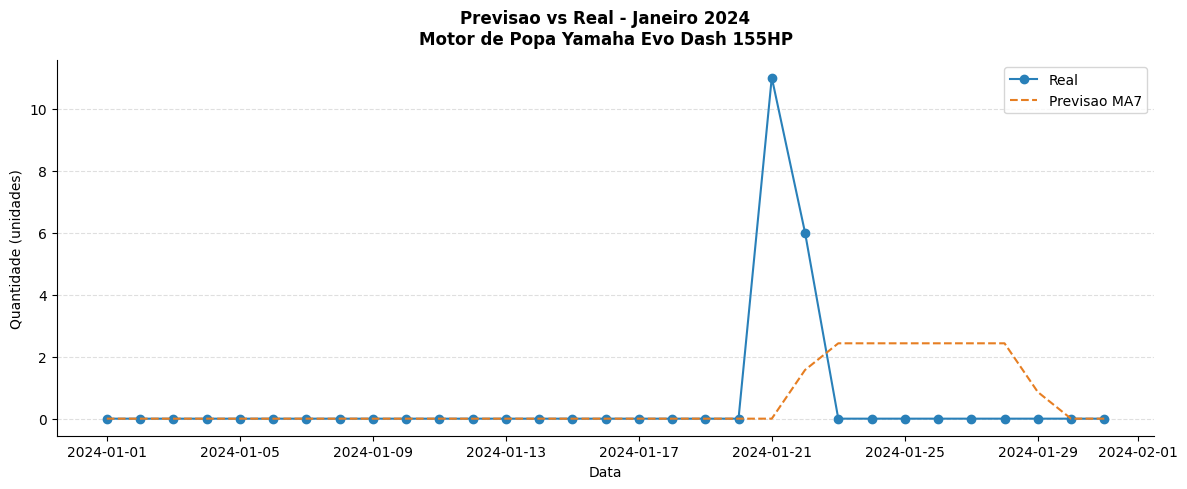

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(teste['data'], teste['qtd'],
        label='Real', color='#2980b9', marker='o', linewidth=1.5)
ax.plot(teste['data'], teste['previsao_ma7'],
        label='Previsao MA7', color='#e67e22', linestyle='--', linewidth=1.5)

ax.set_title('Previsao vs Real - Janeiro 2024\nMotor de Popa Yamaha Evo Dash 155HP',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Data')
ax.set_ylabel('Quantidade (unidades)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


---
## Avaliação do baseline

### a) O baseline é adequado para esse produto?

Não. O produto tem vendas muito dispersas — em Janeiro de 2024, apenas 2 dos 31 dias tiveram venda, que foram os dias 21 e 22. O modelo passa a maior parte do tempo prevendo zero, o que coincide com a realidade na maioria dos dias e resulta em um MAE de 0,99 aparentemente baixo. Porem, nos dois dias em que houve venda (11 e 6 unidades), o modelo errou bastante — exatamente quando o erro mais importa para o planejamento de estoque.

### b) Cite uma limitação desse método

A media movel e reativa, nao preditiva: ela so consegue reagir a padroes recentes e nao captura sazonalidade, tendencias de longo prazo ou picos de demanda isolados. Para produtos de venda esporadica o modelo tende a prever zero na maior parte do tempo, ignorando que picos podem ocorrer a qualquer momento.

### Questão 7.1

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # ── 1. Carregar e filtrar o produto ───────────────────────────────────────────
# df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# def parse_date(s):
#     for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
#         try: return pd.to_datetime(s, format=fmt)
#         except: pass

# df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# PRODUTO_ID = 54  # Motor de Popa Yamaha Evo Dash 155HP
# df_prod = df_vendas[df_vendas['id_product'] == PRODUTO_ID].copy()

# # ── 2. Série temporal diária (com zeros para dias sem venda) ──────────────────
# todas_datas = pd.date_range('2023-01-01', '2024-01-31', freq='D')
# df_serie = pd.DataFrame({'data': todas_datas})

# diario = df_prod.groupby(df_prod['sale_date'].dt.date)['qtd'].sum().reset_index()
# diario.columns = ['data', 'qtd']
# diario['data'] = pd.to_datetime(diario['data'])

# df_serie = df_serie.merge(diario, on='data', how='left').fillna(0)
# df_serie['qtd'] = df_serie['qtd'].astype(int)

# # ── 3. Média móvel 7 dias (sem data leakage) ──────────────────────────────────
# df_serie['previsao_ma7'] = (
#     df_serie['qtd']
#     .shift(1)                        # desloca 1 dia: dia atual não entra no cálculo
#     .rolling(window=7, min_periods=1) # janela dos 7 dias anteriores
#     .mean()
#     .round(2)
# )

# # ── 4. Treino e teste ─────────────────────────────────────────────────────────
# treino = df_serie[df_serie['data'] <= '2023-12-31'].copy()
# teste  = df_serie[df_serie['data'] >= '2024-01-01'].copy()

# # ── 5. MAE ────────────────────────────────────────────────────────────────────
# mae = (teste['qtd'] - teste['previsao_ma7']).abs().mean()
# print(f'MAE: {mae:.4f}')

# # ── 6. Gráfico ────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(teste['data'], teste['qtd'], label='Real', color='#2980b9', marker='o', linewidth=1.5)
# ax.plot(teste['data'], teste['previsao_ma7'], label='Previsão MA7', color='#e67e22', linestyle='--', linewidth=1.5)
# ax.set_title('Previsão vs Real — Janeiro 2024\nMotor de Popa Yamaha Evo Dash 155HP', fontsize=12, fontweight='bold')
# ax.set_xlabel('Data')
# ax.set_ylabel('Quantidade (unidades)')
# ax.legend()
# ax.grid(axis='y', linestyle='--', alpha=0.4)
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.savefig('../data/processed/previsao_demanda_yamaha.png', dpi=150, bbox_inches='tight')
# plt.show()


### Questão 7.2
A soma total da previsão para a primeira semana de Janeiro de 2024 (01/01 a 07/01) é 0 unidades. Isso ocorre porque os últimos 7 dias de dezembro de 2023 (25 a 31/dez) não tiveram nenhuma venda registrada do produto — portanto a média móvel desses 7 dias é zero, e essa previsão se propaga para toda a primeira semana de janeiro.

### Questão 7.3
O baseline foi construído calculando, para cada dia do período de teste, a média aritmética das últimas 7 observações diárias de quantidade vendida — incluindo os dias com zero venda, não apenas os dias com transação. A série diária foi montada com um calendário completo (igual à Questão 6), preenchendo com 0 todos os dias sem venda, garantindo que a janela de 7 dias sempre represente 7 dias corridos de fato.

O data leakage foi evitado com o .shift(1) aplicado antes do .rolling(7): isso desloca a série um dia para frente, fazendo com que a previsão de cada dia seja calculada exclusivamente com dados anteriores a ele — o valor do próprio dia nunca entra no cálculo da sua previsão.

A principal limitação é que a média móvel é reativa e estacionária, ela assume que o futuro será parecido com os últimos 7 dias. Para um produto de demanda esparsa como este — onde a maioria dos dias é zero e os picos aparecem de forma irregular — o modelo quase sempre prevê zero ou valores muito baixos, sendo incapaz de antecipar os picos de demanda que são justamente os mais críticos para o planejamento de estoque.